Columns:
 Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

Sample Data:
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  

Using text column: Resume_str

Top Candidates:
      Match Score
1339    24.580571
926     20.270145
1762    17.869064
1218

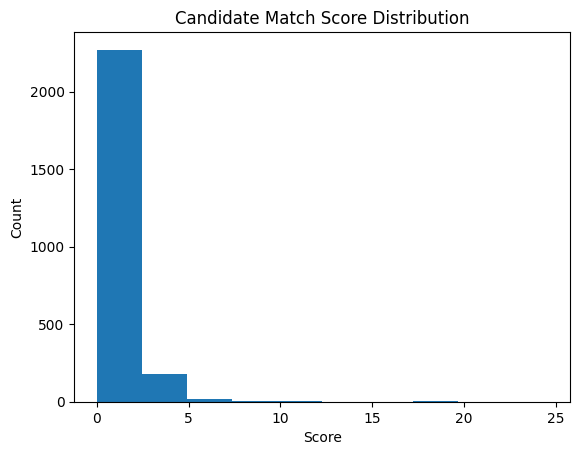


File saved: ranked_candidates.csv


In [6]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# LOAD DATA (robust)
df = pd.read_csv(
    "/content/FT3_Dataset.csv",
    encoding='latin1',
    engine='python',
    on_bad_lines='skip'
)

print("Columns:\n", df.columns)
print("\nSample Data:")
print(df.head())

# CLEAN TEXT FUNCTION
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

# AUTO-DETECT RESUME COLUMN
text_col = None

for col in df.columns:
    if df[col].dtype == 'object':
        try:
            if df[col].astype(str).str.len().mean() > 50:
                text_col = col
                break
        except:
            continue

print("\nUsing text column:", text_col)

# SAFETY CHECK
if text_col is None:
    raise ValueError("No suitable resume column found")

# CLEAN RESUME TEXT
df['clean_resume'] = df[text_col].apply(clean_text)

# JOB DESCRIPTION (you can modify)
job_description = """
Looking for a data analyst with skills in python, machine learning,
data analysis, pandas, numpy, visualization, and statistics.
"""

job_clean = clean_text(job_description)

# TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')

resume_vectors = vectorizer.fit_transform(df['clean_resume'])
job_vector = vectorizer.transform([job_clean])

# SIMILARITY
similarity_scores = cosine_similarity(resume_vectors, job_vector)

df['Match Score'] = similarity_scores * 100

# SORT CANDIDATES
df = df.sort_values(by='Match Score', ascending=False)

print("\nTop Candidates:")
print(df[['Match Score']].head())

# SKILL EXTRACTION
skills = ["python", "machine learning", "data analysis", "pandas", "numpy", "sql", "statistics"]

def extract_skills(text):
    return ", ".join([skill for skill in skills if skill in text])

df['Skills Found'] = df['clean_resume'].apply(extract_skills)

def missing_skills(text):
    return ", ".join([skill for skill in skills if skill not in text])

df['Missing Skills'] = df['clean_resume'].apply(missing_skills)

# VISUALIZATION
plt.figure()
plt.hist(df['Match Score'], bins=10)
plt.title("Candidate Match Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

# SAVE OUTPUT
df.to_csv("ranked_candidates.csv", index=False)

print("\nFile saved: ranked_candidates.csv")